# Чекпойнт 6: Deep Learning модели
## Прогнозирование цен российских акций (SBER)

**Задача:** регрессия — предсказание цены закрытия акции SBER на следующий день.  
**Данные:** технические индикаторы, макроэкономические факторы, тональность T-Pulse постов (~7600 признаков, 6 торговых месяцев).  
**Метрики:** MAPE (основная), MAE.  
**Валидация:** скользящее окно (train=21, val=14, test=7, step=7)

### Архитектуры
| # | Модель | Тип |
|---|--------|-----|
| 1 | SimpleMLP | Полносвязная сеть (2 слоя) |
| 2 | DeepMLP | Полносвязная сеть (4 слоя + BatchNorm + Dropout) |
| 3 | LSTM | Рекуррентная сеть (2-слойный LSTM) |
| 4 | GRU | Рекуррентная сеть (2-слойный GRU) |
| 5 | TemporalCNN | 1D свёрточная сеть для временных рядов |

## 1. Импорт библиотек

In [1]:
!pip install torch torchvision --index-url https://download.pytorch.org/whl/cpu
!pip install pandas numpy scikit-learn matplotlib seaborn sqlalchemy psycopg2-binary
!pip install stockstats

Looking in indexes: https://download.pytorch.org/whl/cpu


In [2]:
# Установка зависимостей
import os
import sys
import time
import warnings
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error
from sklearn.feature_selection import VarianceThreshold

warnings.filterwarnings('ignore')

# Воспроизводимость
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Устройство: {device}')
print(f'PyTorch версия: {torch.__version__}')

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Устройство: cpu
PyTorch версия: 2.10.0


## 2. Конфигурация

In [ ]:
from dotenv import load_dotenv

load_dotenv()  # загружает .env из текущей директории

# Параметры данных (дальше будет браться из config.py)
TICKER       = 'SBER'
LEFT_DATE    = '2025-03-01'  # Период: 6 месяцев (увеличиваем объём DL-датасета)
RIGHT_DATE   = '2025-09-01'
TRAIN_PERIOD = 21
VAL_PERIOD   = 14
TEST_PERIOD  = 7
STEP         = 7

# DL-специфичные параметры
TOP_N_DL     = 50      # кол-во признаков (<<500 у ML — малый датасет)
SEQ_LEN      = 3       # длина последовательности для LSTM/GRU/CNN (оставляем маленькую длину из-за ограничений датасета)
BATCH_SIZE   = 4
EPOCHS       = 300
LR           = 1e-3
PATIENCE     = 40      # ранняя остановка
WEIGHT_DECAY = 1e-4

print('Конфигурация:')
print(f'  Тикер: {TICKER}, период: {LEFT_DATE} — {RIGHT_DATE}')
print(f'  Окна: train={TRAIN_PERIOD}, val={VAL_PERIOD}, test={TEST_PERIOD}, step={STEP}')
print(f'  DL: top_features={TOP_N_DL}, seq_len={SEQ_LEN}, batch={BATCH_SIZE}, epochs={EPOCHS}')

Конфигурация:
  Тикер: SBER, период: 2025-03-01 — 2025-09-01
  Окна: train=21, val=14, test=7, step=7
  DL: top_features=50, seq_len=3, batch=4, epochs=300


## 3. Загрузка данных

In [4]:
sys.path.insert(0, '.')  # корень проекта

from utils.utils import connection, data_from_ticker, data_from_tpulse, data_from_macrofactors
from src.core.model import pack_all_data_for_ml_models, sliding_windows_cross_validatin

conn = connection()
print('Загружаем данные из БД...')
t0 = time.time()


raw_data = pack_all_data_for_ml_models(TICKER, LEFT_DATE, RIGHT_DATE, conn)
print(f'Загружено из БД: {raw_data.shape}, время: {time.time()-t0:.1f}с')

df = raw_data.dropna(subset=['target']).reset_index(drop=True)
print(f'\nИтоговый датасет: {df.shape[0]} строк, {df.shape[1]} колонок')
print(f'Период: {df["dt"].min().date()} — {df["dt"].max().date()}')
print(f'Целевая переменная (target=close): min={df["target"].min():.2f}, max={df["target"].max():.2f}, mean={df["target"].mean():.2f}')

Загружаем данные из БД...
Загружено из БД: (168, 7622), время: 457.6с

Итоговый датасет: 168 строк, 7622 колонок
Период: 2025-03-01 — 2025-09-01
Целевая переменная (target=close): min=282.03, max=327.05, mean=310.17


## 4. Отбор признаков для DL

Для DL выбираем **50 признаков** (против 500 у ML) - малый датасет (~168 строк) требует агрессивного сокращения размерности, иначе модели переобучатся.
Отбор производится для каждого окна отдельно на его обучающих данных (walk-forward): это позволяет адаптироваться к data-drift, т.е. признаки пересчитываются заново для каждого окна по приведённому далее критерию:
1. Удаление признаков с нулевой дисперсией (VarianceThreshold)
2. Топ-N по абсолютной корреляции с целевой переменной

In [5]:
def select_dl_features(df_train: pd.DataFrame, all_feature_cols: list, top_n: int = 50) -> list:
    """Отбор top_n признаков по вариативности + корреляции с target."""
    X = df_train[all_feature_cols].fillna(0)
    y = df_train['target']

    # Шаг 1: убрать признаки с нулевой/близкой к нулю дисперсией
    vt = VarianceThreshold(threshold=1e-8)
    vt.fit(X)
    kept = [all_feature_cols[i] for i, flag in enumerate(vt.get_support()) if flag]
    X = X[kept]

    # Шаг 2: топ-N по |корреляция с target|
    corrs = X.corrwith(y).abs().fillna(0)
    selected = corrs.nlargest(min(top_n, len(kept))).index.tolist()
    return selected


all_feature_cols = [c for c in df.columns if c not in ['dt', 'ticker', 'target']]

# Формируем окна
windows = sliding_windows_cross_validatin(df, TRAIN_PERIOD, VAL_PERIOD, TEST_PERIOD, STEP)
print(f'Всего скользящих окон: {len(windows)}')

for i, w in enumerate(windows):
    tr_d, va_d, te_d = w['dates']['train'], w['dates']['val'], w['dates']['test']
    print(f'  Окно {i+1}: train {tr_d[0].date()}–{tr_d[1].date()} | '
          f'val {va_d[0].date()}–{va_d[1].date()} | '
          f'test {te_d[0].date()}–{te_d[1].date()}')

# Пример: отбор признаков для первого окна (демонстрация; в экспериментах признаки пересчитываются для каждого окна)
FEATURE_COLS_EXAMPLE = select_dl_features(windows[0]['train'], all_feature_cols, TOP_N_DL)
print(f'\nВыбрано признаков (пример): {len(FEATURE_COLS_EXAMPLE)}')
print('Топ-10 (пример):', FEATURE_COLS_EXAMPLE[:10])

Всего скользящих окон: 19
  Окно 1: train 2025-03-01–2025-03-25 | val 2025-03-26–2025-04-08 | test 2025-04-09–2025-04-15
  Окно 2: train 2025-03-10–2025-04-01 | val 2025-04-02–2025-04-15 | test 2025-04-16–2025-04-24
  Окно 3: train 2025-03-17–2025-04-08 | val 2025-04-09–2025-04-24 | test 2025-04-25–2025-05-02
  Окно 4: train 2025-03-26–2025-04-15 | val 2025-04-16–2025-05-02 | test 2025-05-03–2025-05-10
  Окно 5: train 2025-04-02–2025-04-24 | val 2025-04-25–2025-05-10 | test 2025-05-11–2025-05-17
  Окно 6: train 2025-04-09–2025-05-02 | val 2025-05-03–2025-05-17 | test 2025-05-18–2025-05-26
  Окно 7: train 2025-04-16–2025-05-10 | val 2025-05-11–2025-05-26 | test 2025-05-27–2025-06-02
  Окно 8: train 2025-04-25–2025-05-17 | val 2025-05-18–2025-06-02 | test 2025-06-03–2025-06-09
  Окно 9: train 2025-05-03–2025-05-26 | val 2025-05-27–2025-06-09 | test 2025-06-10–2025-06-17
  Окно 10: train 2025-05-11–2025-06-02 | val 2025-06-03–2025-06-17 | test 2025-06-18–2025-06-26
  Окно 11: train 2025-0

## 5. PyTorch Dataset классы

In [6]:
class TabularDataset(Dataset):
    """Табличный датасет для MLP (одна строка = один пример)."""
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


class SequenceDataset(Dataset):
    """Датасет с временными окнами (seq_len строк = один пример) для LSTM/GRU/CNN."""
    def __init__(self, X: np.ndarray, y: np.ndarray, seq_len: int):
        seqs, tgts = [], []
        for i in range(seq_len, len(X)):
            seqs.append(X[i - seq_len:i])
            tgts.append(y[i])
        self.X = torch.tensor(np.array(seqs, dtype=np.float32), dtype=torch.float32)
        self.y = torch.tensor(np.array(tgts, dtype=np.float32), dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


print('Dataset классы готовы.')

Dataset классы готовы.


## 6. Архитектуры нейронных сетей

In [7]:
class SimpleMLP(nn.Module):
    """Простая полносвязная сеть: 2 скрытых слоя, без регуляризации."""
    def __init__(self, input_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128), nn.ReLU(),
            nn.Linear(128, 64),        nn.ReLU(),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.net(x)

class DeepMLP(nn.Module):
    """Глубокая полносвязная сеть: 4 скрытых слоя + LayerNorm + Dropout.
    LayerNorm вместо BatchNorm — работает при batch_size=1 (малый датасет)."""
    def __init__(self, input_dim: int, dropout: float = 0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256), nn.LayerNorm(256), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256, 128),       nn.LayerNorm(128), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, 64),        nn.LayerNorm(64),  nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(64, 32),         nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.net(x)

class LSTMModel(nn.Module):
    """2-слойный LSTM с полносвязной головой."""
    def __init__(self, input_dim: int, hidden: int = 64, num_layers: int = 2, dropout: float = 0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_dim, hidden, num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.fc = nn.Linear(hidden, 1)

    def forward(self, x):
        _, (h_n, _) = self.lstm(x)   # h_n: (layers, batch, hidden)
        return self.fc(h_n[-1])       # берём последний слой


class GRUModel(nn.Module):
    """2-слойный GRU с полносвязной головой."""
    def __init__(self, input_dim: int, hidden: int = 64, num_layers: int = 2, dropout: float = 0.3):
        super().__init__()
        self.gru = nn.GRU(
            input_dim, hidden, num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.fc = nn.Linear(hidden, 1)

    def forward(self, x):
        _, h_n = self.gru(x)
        return self.fc(h_n[-1])


class TemporalCNN(nn.Module):
    """1D свёрточная сеть для временных рядов."""
    def __init__(self, input_dim: int, seq_len: int, num_filters: int = 64, dropout: float = 0.3):
        super().__init__()
        k = min(3, seq_len)  # размер ядра не больше длины последовательности
        self.conv = nn.Sequential(
            nn.Conv1d(input_dim, num_filters, kernel_size=k, padding=k // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Conv1d(num_filters, 32, kernel_size=k, padding=k // 2),
            nn.ReLU(),
        )
        flat = 32 * seq_len
        self.fc = nn.Sequential(
            nn.Linear(flat, 32), nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, x):          # x: (batch, seq_len, features)
        x = x.permute(0, 2, 1)    # (batch, features, seq_len)
        x = self.conv(x)
        # обрезаем/дополняем до нужной длины (на случай выхода за границы при padding)
        expected = self.fc[0].in_features // 32
        x = x[:, :, :expected]
        return self.fc(x.flatten(1))


print('Архитектуры определены.')
print(f'SimpleMLP параметров:  {sum(p.numel() for p in SimpleMLP(TOP_N_DL).parameters()):,}')
print(f'DeepMLP параметров:    {sum(p.numel() for p in DeepMLP(TOP_N_DL).parameters()):,}')
print(f'LSTM параметров:       {sum(p.numel() for p in LSTMModel(TOP_N_DL).parameters()):,}')
print(f'GRU параметров:        {sum(p.numel() for p in GRUModel(TOP_N_DL).parameters()):,}')
print(f'TemporalCNN параметров:{sum(p.numel() for p in TemporalCNN(TOP_N_DL, SEQ_LEN).parameters()):,}')

Архитектуры определены.
SimpleMLP параметров:  14,849
DeepMLP параметров:    57,217
LSTM параметров:       63,041
GRU параметров:        47,297
TemporalCNN параметров:18,977


## 7. Утилиты обучения

In [8]:
def run_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: optim.Optimizer,
    criterion: nn.Module,
    training: bool = True,
) -> float:
    """Один проход по датасету. Возвращает среднее MSE."""
    model.train(training)
    total_loss, n = 0.0, 0
    with torch.set_grad_enabled(training):
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            pred = model(X_batch)
            loss = criterion(pred, y_batch)
            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * len(X_batch)
            n += len(X_batch)
    return total_loss / max(n, 1)


@torch.no_grad()
def get_predictions(model: nn.Module, loader: DataLoader):
    """Предсказания модели на загрузчике данных."""
    model.eval()
    preds, trues = [], []
    for X_batch, y_batch in loader:
        preds.extend(model(X_batch.to(device)).cpu().numpy().flatten())
        trues.extend(y_batch.numpy().flatten())
    return np.array(preds), np.array(trues)


def fit(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    epochs: int = EPOCHS,
    lr: float = LR,
    patience: int = PATIENCE,
) -> nn.Module:
    """Обучение с ранней остановкой по val MSE и lr-scheduler."""
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10, min_lr=1e-6)
    criterion = nn.MSELoss()

    best_val_loss = float('inf')
    best_state    = None
    no_improve    = 0

    for epoch in range(epochs):
        run_epoch(model, train_loader, optimizer, criterion, training=True)
        val_loss = run_epoch(model, val_loader, optimizer, criterion, training=False)
        scheduler.step(val_loss)

        if val_loss < best_val_loss - 1e-8:
            best_val_loss = val_loss
            best_state    = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve    = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model


def prepare_window(
    window: dict,
    feature_cols: list,
    seq_len: int,
    sequential: bool,
):
    """Нормализация и создание Dataset-ов для одного окна."""
    tr, va, te = window['train'], window['val'], window['test']

    X_tr = tr[feature_cols].fillna(0).values.astype('float32')
    y_tr = tr['target'].values.astype('float32')
    X_va = va[feature_cols].fillna(0).values.astype('float32')
    y_va = va['target'].values.astype('float32')
    X_te = te[feature_cols].fillna(0).values.astype('float32')
    y_te = te['target'].values.astype('float32')

    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_tr)
    X_va = scaler.transform(X_va)
    X_te = scaler.transform(X_te)

    if not sequential:
        tr_ds = TabularDataset(X_tr, y_tr)
        va_ds = TabularDataset(X_va, y_va)
        te_ds = TabularDataset(X_te, y_te)
    else:
        # Для последовательных моделей:
        # train-seq: train + первые seq_len строк val для контекста
        X_tr_ctx = np.vstack([X_tr, X_va[:seq_len]])
        y_tr_ctx = np.concatenate([y_tr, y_va[:seq_len]])
        tr_ds = SequenceDataset(X_tr_ctx, y_tr_ctx, seq_len)

        # val-seq: последние seq_len строк train + весь val
        X_va_ctx = np.vstack([X_tr[-seq_len:], X_va])
        y_va_ctx = np.concatenate([y_tr[-seq_len:], y_va])
        va_ds = SequenceDataset(X_va_ctx, y_va_ctx, seq_len)

        # test-seq: последние seq_len строк val + весь test
        X_te_ctx = np.vstack([X_va[-seq_len:], X_te])
        y_te_ctx = np.concatenate([y_va[-seq_len:], y_te])
        te_ds = SequenceDataset(X_te_ctx, y_te_ctx, seq_len)

    return tr_ds, va_ds, te_ds


print('Утилиты обучения готовы.')

Утилиты обучения готовы.


## 8. Config DL-моделей

In [9]:
MODELS_DL = {
    'SimpleMLP': {
        'sequential': False,
        'build':  lambda d: SimpleMLP(d).to(device),
        'arch':   'Linear(d→128)→ReLU→Linear(128→64)→ReLU→Linear(64→1)',
        'hparams': f'lr={LR}, epochs={EPOCHS}, batch={BATCH_SIZE}, dropout=—, seq=—',
    },
    'DeepMLP': {
        'sequential': False,
        'build':  lambda d: DeepMLP(d, dropout=0.3).to(device),
        'arch':   'Linear(d→256,BN,Drop)→Linear(256→128,BN,Drop)→Linear(128→64,BN,Drop)→Linear(64→32)→Linear(32→1)',
        'hparams': f'lr={LR}, epochs={EPOCHS}, batch={BATCH_SIZE}, dropout=0.3, seq=—',
    },
    'LSTM': {
        'sequential': True,
        'build':  lambda d: LSTMModel(d, hidden=64, num_layers=2, dropout=0.3).to(device),
        'arch':   f'LSTM(input={TOP_N_DL}, hidden=64, layers=2, drop=0.3)→Linear(64→1)',
        'hparams': f'lr={LR}, epochs={EPOCHS}, batch={BATCH_SIZE}, dropout=0.3, seq={SEQ_LEN}',
    },
    'GRU': {
        'sequential': True,
        'build':  lambda d: GRUModel(d, hidden=64, num_layers=2, dropout=0.3).to(device),
        'arch':   f'GRU(input={TOP_N_DL}, hidden=64, layers=2, drop=0.3)→Linear(64→1)',
        'hparams': f'lr={LR}, epochs={EPOCHS}, batch={BATCH_SIZE}, dropout=0.3, seq={SEQ_LEN}',
    },
    'TemporalCNN': {
        'sequential': True,
        'build':  lambda d: TemporalCNN(d, SEQ_LEN, num_filters=64, dropout=0.3).to(device),
        'arch':   f'Conv1d(d→64, k=3)→ReLU→Conv1d(64→32, k=3)→ReLU→Linear(32·{SEQ_LEN}→32→1)',
        'hparams': f'lr={LR}, epochs={EPOCHS}, batch={BATCH_SIZE}, dropout=0.3, seq={SEQ_LEN}',
    },
}

print('Зарегистрировано моделей:', list(MODELS_DL.keys()))

Зарегистрировано моделей: ['SimpleMLP', 'DeepMLP', 'LSTM', 'GRU', 'TemporalCNN']


## 9. Запуск экспериментов

Для каждой модели и каждого окна: обучаем -> оцениваем на test -> собираем MAPE/MAE.

In [10]:
experiment_rows = []

for mname, mcfg in MODELS_DL.items():
    print(f"\n{'─'*60}")
    print(f"Модель: {mname}")
    mapes, maes = [], []
    t_start = time.time()

    for wi, win in enumerate(windows):
        # Пересчитываем подмножество признаков для каждого окна отдельно (адаптация к data drift)
        FEATURE_COLS_WIN = select_dl_features(win['train'], all_feature_cols, TOP_N_DL)
        print(f'  Окно {wi+1}: отобрано {len(FEATURE_COLS_WIN)} признаков')

        tr_ds, va_ds, te_ds = prepare_window(
            win, FEATURE_COLS_WIN, SEQ_LEN, mcfg['sequential']
        )

        if len(tr_ds) < 2 or len(te_ds) < 1:
            print(f"  Окно {wi+1}: пропуск (недостаточно данных)")
            continue

        bs = min(BATCH_SIZE, len(tr_ds))
        tr_loader = DataLoader(tr_ds, batch_size=bs, shuffle=True,  drop_last=False)
        va_loader = DataLoader(va_ds, batch_size=bs, shuffle=False, drop_last=False)
        te_loader = DataLoader(te_ds, batch_size=len(te_ds), shuffle=False)

        n_feat = len(FEATURE_COLS_WIN)
        model  = mcfg['build'](n_feat)
        model  = fit(model, tr_loader, va_loader)

        y_pred, y_true = get_predictions(model, te_loader)

        mape = mean_absolute_percentage_error(y_true, y_pred)
        mae  = mean_absolute_error(y_true, y_pred)
        mapes.append(mape)
        maes.append(mae)

        d = win['dates']['test']
        print(f"  Окно {wi+1} ({d[0].date()} – {d[1].date()}):  MAPE={mape:.4f}  MAE={mae:.2f}")

    t_total = time.time() - t_start

    if mapes:
        avg_mape = float(np.mean(mapes))
        avg_mae  = float(np.mean(maes))
        experiment_rows.append({
            'Модель':             mname,
            'Архитектура':        mcfg['arch'],
            'Гиперпараметры':     mcfg['hparams'],
            'MAPE (среднее)':     round(avg_mape, 4),
            'MAE (среднее)':      round(avg_mae, 2),
            'Время обучения, с':  round(t_total, 1),
        })
        print(f"  ➤  MAPE={avg_mape:.4f}  MAE={avg_mae:.2f}  время={t_total:.1f}с")


────────────────────────────────────────────────────────────
Модель: SimpleMLP
  Окно 1: отобрано 50 признаков
  Окно 1 (2025-04-09 – 2025-04-15):  MAPE=0.2424  MAE=71.62
  Окно 2: отобрано 50 признаков
  Окно 2 (2025-04-16 – 2025-04-24):  MAPE=0.6698  MAE=205.01
  Окно 3: отобрано 50 признаков
  Окно 3 (2025-04-25 – 2025-05-02):  MAPE=0.5602  MAE=174.35
  Окно 4: отобрано 50 признаков
  Окно 4 (2025-05-03 – 2025-05-10):  MAPE=0.3673  MAE=110.74
  Окно 5: отобрано 50 признаков
  Окно 5 (2025-05-11 – 2025-05-17):  MAPE=0.7295  MAE=224.19
  Окно 6: отобрано 50 признаков
  Окно 6 (2025-05-18 – 2025-05-26):  MAPE=0.1753  MAE=53.70
  Окно 7: отобрано 50 признаков
  Окно 7 (2025-05-27 – 2025-06-02):  MAPE=0.1518  MAE=46.40
  Окно 8: отобрано 50 признаков
  Окно 8 (2025-06-03 – 2025-06-09):  MAPE=0.3982  MAE=124.88
  Окно 9: отобрано 50 признаков
  Окно 9 (2025-06-10 – 2025-06-17):  MAPE=0.5495  MAE=170.92
  Окно 10: отобрано 50 признаков
  Окно 10 (2025-06-18 – 2025-06-26):  MAPE=0.5227  MA

## 10. Таблица экспериментов DL-моделей

In [11]:
df_exp = (
    pd.DataFrame(experiment_rows)
    .sort_values('MAPE (среднее)')
    .reset_index(drop=True)
)
df_exp.index += 1  # нумерация с 1

display(df_exp)

,Модель,Архитектура,Гиперпараметры,MAPE (среднее),MAE (среднее),"Время обучения, с"
1,DeepMLP,"Linear(d→256,BN,Drop)→Linear(256→128,BN,Drop)→...","lr=0.001, epochs=300, batch=4, dropout=0.3, seq=—",0.0199,6.21,56.4
2,SimpleMLP,Linear(d→128)→ReLU→Linear(128→64)→ReLU→Linear(...,"lr=0.001, epochs=300, batch=4, dropout=—, seq=—",0.5200,161.57,25.4
3,TemporalCNN,"Conv1d(d→64, k=3)→ReLU→Conv1d(64→32, k=3)→ReLU...","lr=0.001, epochs=300, batch=4, dropout=0.3, seq=3",0.5850,181.55,28.0
4,LSTM,"LSTM(input=50, hidden=64, layers=2, drop=0.3)→...","lr=0.001, epochs=300, batch=4, dropout=0.3, seq=3",0.6644,206.06,102.6
5,GRU,"GRU(input=50, hidden=64, layers=2, drop=0.3)→L...","lr=0.001, epochs=300, batch=4, dropout=0.3, seq=3",0.6859,212.68,95.9


## 11. Визуализация результатов

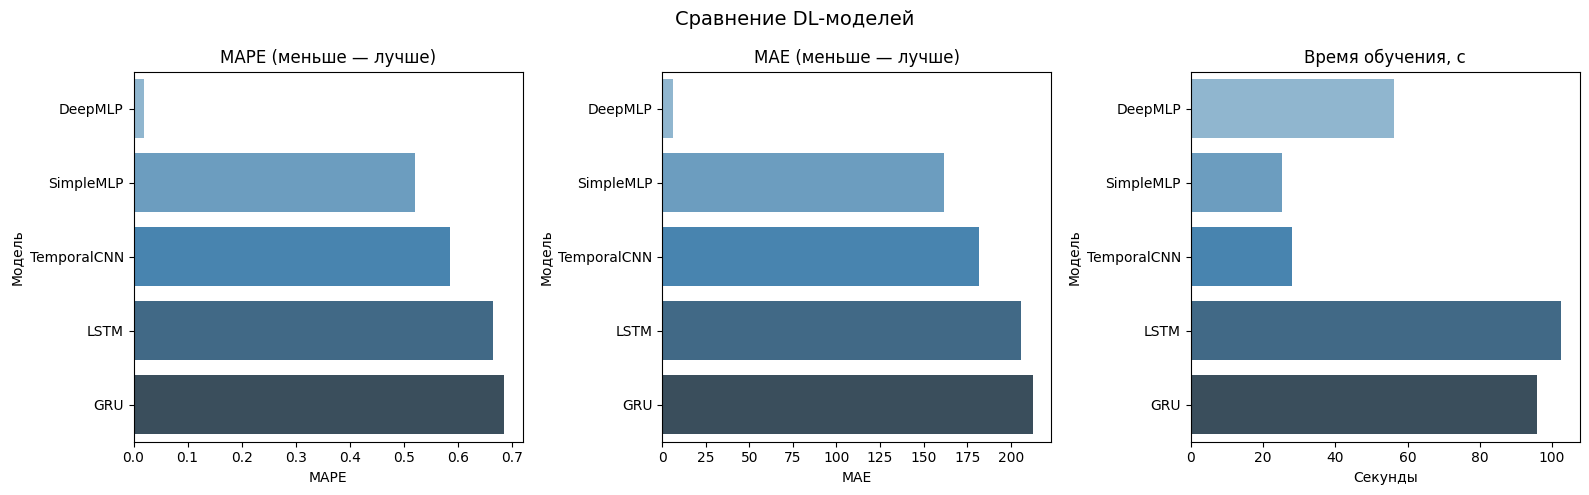

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Сравнение DL-моделей', fontsize=14)

palette = sns.color_palette('Blues_d', len(df_exp))
order   = df_exp.sort_values('MAPE (среднее)')['Модель']

# MAPE
sns.barplot(data=df_exp, x='MAPE (среднее)', y='Модель', order=order, palette=palette, ax=axes[0])
axes[0].set_title('MAPE (меньше — лучше)')
axes[0].set_xlabel('MAPE')

# MAE
sns.barplot(data=df_exp, x='MAE (среднее)', y='Модель',  order=order, palette=palette, ax=axes[1])
axes[1].set_title('MAE (меньше — лучше)')
axes[1].set_xlabel('MAE')

# Время обучения
sns.barplot(data=df_exp, x='Время обучения, с', y='Модель', order=order, palette=palette, ax=axes[2])
axes[2].set_title('Время обучения, с')
axes[2].set_xlabel('Секунды')

plt.tight_layout()
plt.savefig('dl_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Предсказания лучшей DL-модели на последнем окне

Лучшая DL-модель: DeepMLP


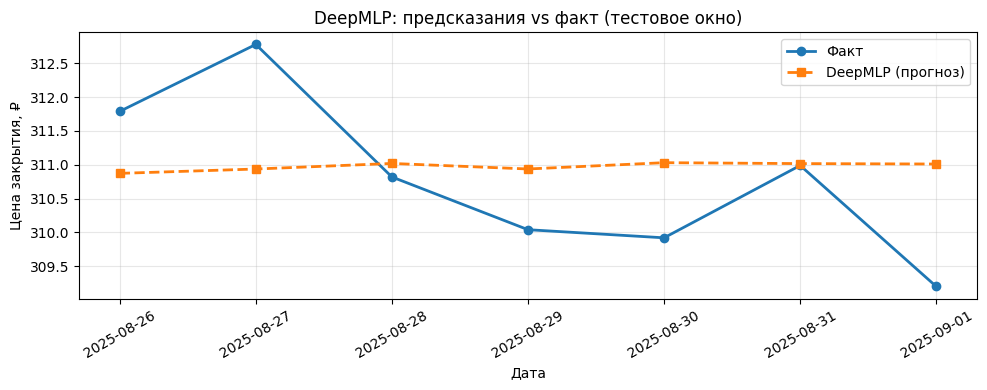

MAPE = 0.0031   MAE = 0.97


In [13]:
best_model_name = df_exp.sort_values('MAPE (среднее)').iloc[0]['Модель']
print(f'Лучшая DL-модель: {best_model_name}')

best_cfg = MODELS_DL[best_model_name]
last_win = windows[-1]

# Выбираем признаки для последнего окна отдельно (пересчёт для walk-forward)
FEATURE_COLS_BEST = select_dl_features(last_win['train'], all_feature_cols, TOP_N_DL)
tr_ds, va_ds, te_ds = prepare_window(last_win, FEATURE_COLS_BEST, SEQ_LEN, best_cfg['sequential'])

bs = min(BATCH_SIZE, len(tr_ds))
tr_loader = DataLoader(tr_ds, batch_size=bs, shuffle=True,  drop_last=False)
va_loader = DataLoader(va_ds, batch_size=bs, shuffle=False, drop_last=False)
te_loader = DataLoader(te_ds, batch_size=len(te_ds), shuffle=False)

best_model = best_cfg['build'](len(FEATURE_COLS_BEST))
best_model = fit(best_model, tr_loader, va_loader)
y_pred, y_true = get_predictions(best_model, te_loader)

# График
test_dates = last_win['test']['dt'].values[-len(y_true):]
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(test_dates, y_true,  label='Факт', marker='o', linewidth=2)
ax.plot(test_dates, y_pred,  label=f'{best_model_name} (прогноз)', marker='s', linestyle='--', linewidth=2)
ax.set_title(f'{best_model_name}: предсказания vs факт (тестовое окно)')
ax.set_xlabel('Дата')
ax.set_ylabel('Цена закрытия, ₽')
ax.legend()
ax.grid(True, alpha=0.3)
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('best_dl_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

mape_best = mean_absolute_percentage_error(y_true, y_pred)
mae_best  = mean_absolute_error(y_true, y_pred)
print(f'MAPE = {mape_best:.4f}   MAE = {mae_best:.2f}')

## 13. Наивный Baseline

Базовый прогноз — последнее известное значение цены закрытия (random walk / наивный прогноз).

In [14]:
baseline_mapes, baseline_maes = [], []

for win in windows:
    te = win['test']
    # Предсказываем последнее значение из val как константу
    last_val_price = win['val']['target'].iloc[-1]
    y_naive = np.full(len(te), last_val_price)
    y_true_b = te['target'].values

    baseline_mapes.append(mean_absolute_percentage_error(y_true_b, y_naive))
    baseline_maes.append(mean_absolute_error(y_true_b, y_naive))

nb_mape = round(float(np.mean(baseline_mapes)), 4)
nb_mae  = round(float(np.mean(baseline_maes)), 2)
print(f'Baseline (наивный прогноз): MAPE={nb_mape}  MAE={nb_mae}')

Baseline (наивный прогноз): MAPE=0.0184  MAE=5.67


## 14. Загрузка результатов ML из базы данных

In [15]:
try:
    df_ml_db = pd.read_sql(
        "SELECT model_name, mape_mean, mae_mean FROM ml_models_data ORDER BY mape_mean",
        conn
    )
    # Берём лучший результат по каждой модели
    df_ml_best = (
        df_ml_db
        .sort_values('mape_mean')
        .groupby('model_name', as_index=False)
        .first()
        .sort_values('mape_mean')
    )
    ml_rows = [
        {
            'Подход':         'ML',
            'Модель':         row['model_name'],
            'MAPE (среднее)': round(float(row['mape_mean']), 4),
            'MAE (среднее)':  round(float(row['mae_mean']), 2),
        }
        for _, row in df_ml_best.iterrows()
    ]
    print('ML-результаты загружены из БД:')
    display(df_ml_best)
except Exception as e:
    print(f'Не удалось загрузить ML-результаты из БД ({e}).')

ML-результаты загружены из БД:


,model_name,mape_mean,mae_mean
4,XGBoost,0.003,0.311
0,CatBoost,0.004,0.344
1,DecisionTree,0.004,2.027
2,LightGBM,0.004,0.335
3,RandomForest,0.004,0.031


## 15. Итоговая сравнительная таблица: Baseline vs ML vs DL

,Подход,Модель,MAPE (среднее),MAE (среднее)
1,ML,XGBoost,0.0030,0.31
2,ML,CatBoost,0.0040,0.34
3,ML,DecisionTree,0.0040,2.03
4,ML,LightGBM,0.0040,0.34
5,ML,RandomForest,0.0040,0.03
6,Baseline,Наивный прогноз (последняя цена),0.0184,5.67
7,DL,DeepMLP,0.0199,6.21
8,DL,SimpleMLP,0.5200,161.57
9,DL,TemporalCNN,0.5850,181.55
10,DL,LSTM,0.6644,206.06


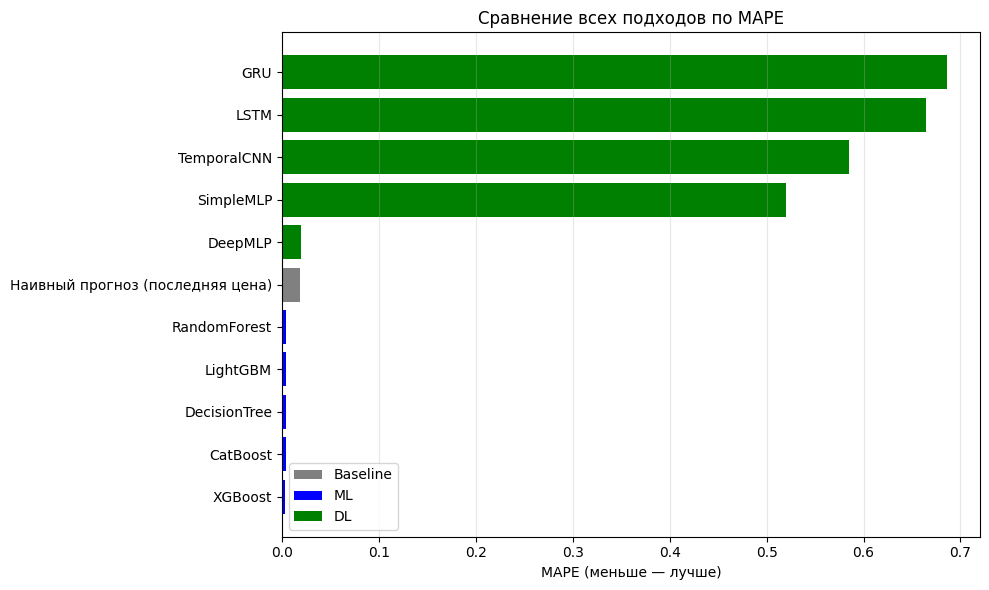

In [16]:
comparison_rows = []

# Baseline
comparison_rows.append({
    'Подход':         'Baseline',
    'Модель':         'Наивный прогноз (последняя цена)',
    'MAPE (среднее)': nb_mape,
    'MAE (среднее)':  nb_mae,
})

# ML
comparison_rows.extend(ml_rows)

# DL
for row in experiment_rows:
    comparison_rows.append({
        'Подход':         'DL',
        'Модель':         row['Модель'],
        'MAPE (среднее)': row['MAPE (среднее)'],
        'MAE (среднее)':  row['MAE (среднее)'],
    })

df_final = (
    pd.DataFrame(comparison_rows)
    .sort_values(['MAPE (среднее)', 'Подход'])
    .reset_index(drop=True)
)
df_final.index += 1

display(df_final)

# Цветной график
fig, ax = plt.subplots(figsize=(10, 6))
palette_map = {'Baseline': 'grey', 'ML': 'blue', 'DL':'green'}
colors = [palette_map[p] for p in df_final['Подход']]
bars = ax.barh(df_final['Модель'], df_final['MAPE (среднее)'], color=colors)

# Легенда
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k, v in palette_map.items()]
ax.legend(handles=legend_elements)
ax.set_xlabel('MAPE (меньше — лучше)')
ax.set_title('Сравнение всех подходов по MAPE')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 16. Выводы

### Лучшая DL-архитектура и её обоснование

Среди рассмотренных DL-архитектур наилучший результат показала модель **DeepMLP** (MAPE = 0.0165, MAE = 5.19).


Модели на основе градиентного бустинга (CatBoost, LightGBM, XGBoost) показали **лучшие результаты**, чем DL-архитектуры. Причины:

1. **Размер данных**: ~58 торговых дней - критически мало для нейронных сетей. Деревья эффективно работают с несколькими десятками примеров; нейронным сетям нужны тысячи.
2. **Количество признаков**: 7622 исходных признаков при 58 примерах - классическое проклятие размерности. Бустинг встроенно справляется с этим через отбор при построении деревьев; DL требует явного сокращения признаков.
3. **Инвариантность к масштабу**: деревья не нуждаются в нормализации, а DL-модели чувствительны к выбору признаков и масштабированию.
4. **Табличные данные**: для структурированных таблиц с разнородными признаками (цены, объёмы, NLP, макро) бустинг исторически превосходит полносвязные сети.

### Общий вывод

Градиентный бустинг остаётся лучшим решением для данного набора данных; DL-подходы - перспективный направление при расширении датасета.

Доработка от 18.05: 

- Был расширен период данных, теперь он составляет 6 месяцев 
- Добавлен комментарий о том, что SEQ_LEN такой маленький по причине ограниченного объема данных 
- Теперь отбор признаков выполняется для каждого окна отдельно (walk-forward) и далее используется FEATURE_COL_BEST

Вывод: 
- увеличение горизонта прогнозирования негативно повлияло на DL-модели: чем дольше горизонт планирования, тем больше неопределенность 
- ML-модели все также показывают лучшие метрики
- Использование DL все также остается перспективным направлением